In [39]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


############
# parameters
############

N_arr = np.arange(2, 10, 1)
nmax  = 60
ω = ω0 = g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.0001)

#############################
# Dicke Hamiltonian
#############################

def dicke_fun(N, nmax, ω, ω0, g):

    # Bosonic mode:
    a  = qt.destroy(nmax)
    Ic = qt.qeye(nmax)
   
    # Spin-1/2 operators:
    jp, jm, jz = qt.sigmap(), qt.sigmam(), qt.sigmaz()

    # Embed single-spin operator into N-spin Hilbert space
    def embed(op, i):
        ops = [qt.qeye(2)]*N
        ops[i] = op
        return qt.tensor(ops)

    Jp = sum(embed(jp, i) for i in range(N))
    Jm = Jp.dag()
    Jz = 0.5 * sum(embed(jz, i) for i in range(N))

    IB = qt.tensor([qt.qeye(2)]*N)
    HB = Jz + 0.5 * N * IB
    

    H = ω  * qt.tensor(a.dag() * a, IB) + ω0 * qt.tensor(Ic, HB) + g * (1.0 / np.sqrt(N) * qt.tensor(a + a.dag(), Jp + Jm))
    
    return H, HB


##################
# Initial state
##################

def initial_state(N, nmax, state):

    if state == "coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state == "fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.tensor([qt.basis(2, 1) for _ in range(N)])
    
    return qt.tensor(psiA, psiB)

##############
# Pnm matrix
##############

def pnm_matrix(rho, H):

    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    pnm = np.zeros((len(e_val), len(e_val)))
    for n in range(len(e_val)):
        for m in range(len(e_val)):
            pnm[n, m] = r_val[m]*abs(e_vec[n].overlap(r_vec[m]))**2

    return pnm, r_val, e_val


############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(pnm * deltaE)


############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2

/opt/anaconda3/lib/python3.12/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


N= 2, τ=0.4808, E_B=1.166853
N= 3, τ=0.5060, E_B=1.872518
N= 4, τ=0.5206, E_B=2.596442
N= 5, τ=0.5303, E_B=3.330653
N= 6, τ=0.5371, E_B=4.069989
N= 7, τ=0.5422, E_B=4.813141
N= 8, τ=0.5461, E_B=5.558183
N= 9, τ=0.5493, E_B=6.305936


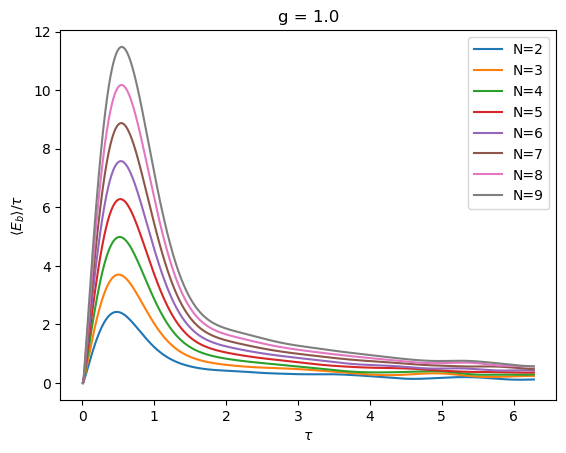

In [40]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

N_arr = np.arange(2, 10, 1)
nmax = 60
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

##############################################
# Plot Battery energy <Eb> as function of time 
# and pick time τ for which <Eb> is maximum
##############################################
τ_list = []

for N in N_arr:

    H, HB = dicke_fun(N, nmax, ω, ω0, g)

    HB_full = qt.tensor(qt.qeye(nmax), HB)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    opts = qt.Options(atol=1e-16, rtol=1e-14)        ## ODE solver options
    # Time evolution
    result = qt.sesolve(H, ψ0, tlist, e_ops=HB_full, options=opts)

    # Battery energy vs time
    Eb_list = np.array(result.expect[0])

    # Maximize charging power (Eb / t)
    power = Eb_list / tlist
    
    idx = np.argmax(power)
    
    τ = tlist[idx]
    
    τ_list.append(τ)

    print(f"N={N:2d}, τ={tlist[idx]:.4f}, E_B={Eb_list[idx]:.6f}")
    
    ##################################
    # Plot of battery energy with time
    ##################################
    
    plt.plot(tlist, power, label=f"N={N}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_b \rangle / \tau$")
plt.legend()
plt.title(f"g = {g}")
plt.show()

N= 2, τ=0.4808, Eb=1.190632, Ergotropy=1.029524, erg/Eb=0.864686352329 Variance=8.2259464545e-01
N= 3, τ=0.5060, Eb=1.908804, Ergotropy=1.739145, erg/Eb=0.911117513418 Variance=1.2453818951e+00
N= 4, τ=0.5206, Eb=2.645386, Ergotropy=2.470733, erg/Eb=0.933978321874 Variance=1.6549355891e+00
N= 5, τ=0.5303, Eb=3.392296, Ergotropy=3.214302, erg/Eb=0.947530124049 Variance=2.0548315175e+00
N= 6, τ=0.5371, Eb=4.144388, Ergotropy=3.964055, erg/Eb=0.956487470104 Variance=2.4478686379e+00
N= 7, τ=0.5422, Eb=4.900310, Ergotropy=4.718218, erg/Eb=0.962840746023 Variance=2.8358777741e+00
N= 8, τ=0.5461, Eb=5.658156, Ergotropy=5.474723, erg/Eb=0.967580687632 Variance=3.2203554382e+00
N= 9, τ=0.5493, Eb=6.418688, Ergotropy=6.234145, erg/Eb=0.971249177173 Variance=3.6016964324e+00


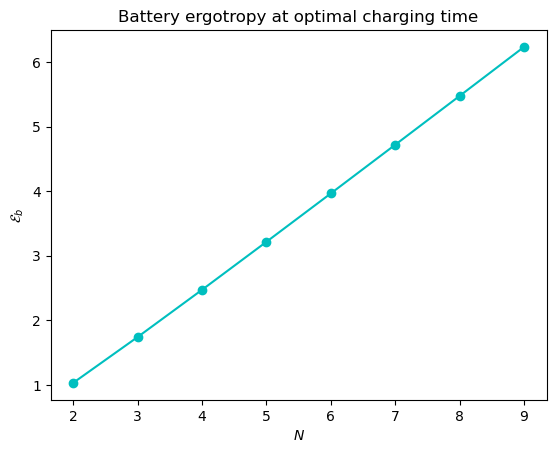

In [41]:
Eb_list = []
erg_list = []
var_list = []
ratio_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB = dicke_fun(N, nmax, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ], options=opts)

    # Full density matrix at τ
    ρ_full = result.states[-1]

    # Partial trace over cavity (subsystem 0)
    ρb = ρ_full.ptrace(list(range(1,N+1)))

    Eb = qt.expect(HB, ρb)
    
    pnm, r_val, e_val = pnm_matrix(ρb, HB)

    # Ergotropy via pnm matrix
    erg = ergotropy_pnm(pnm, r_val, e_val)

    # Variance via pnm matrix
    var = variance_pnm(pnm, r_val, e_val)

    ratio = erg/Eb

    print(f"N={N:2d}, τ={τ:.4f}, Eb={Eb:.6f}, Ergotropy={erg:.6f}, erg/Eb={ratio:.12f} Variance={var:.10e}")

    Eb_list.append(Eb)
    erg_list.append(erg)
    var_list.append(var)
    ratio_list.append(ratio)

Eb_arr = np.array(Eb_list)
erg_arr = np.array(erg_list)
var_arr = np.array(var_list)

rel_fluct = np.sqrt(var_arr) / erg_arr

rel_fluc = np.sqrt(var_arr) / Eb_arr

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.figure()
plt.plot(N_arr, erg_list, 'o-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("WS1.png")
plt.show()

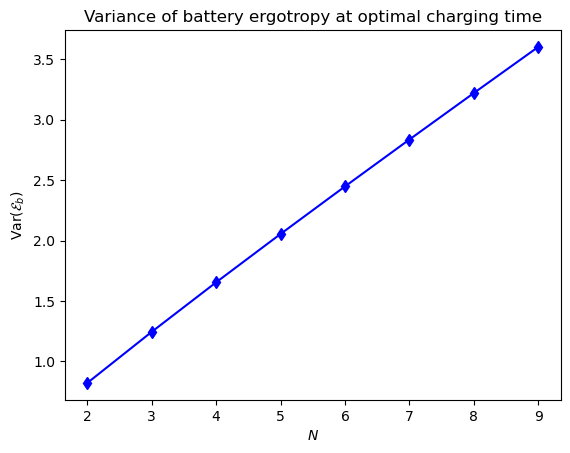

In [42]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, var_list, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("WS2.png")
plt.show()

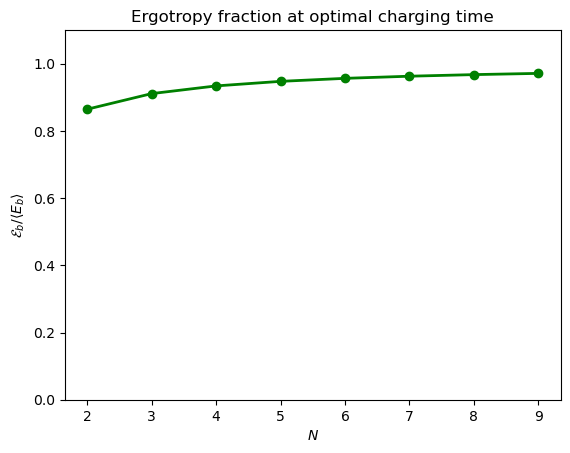

In [43]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
#############################################################


plt.figure()
plt.plot(N_arr, ratio_list, 'o-', color='g', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
#plt.savefig("WS3.png")
plt.show()

N= 2, τ=0.4808, Relative Fluctuation =0.880960936870, Relative Fluctuation with Eb =0.761754899046
N= 3, τ=0.5060, Relative Fluctuation =0.641675700248, Relative Fluctuation with Eb =0.584641968431
N= 4, τ=0.5206, Relative Fluctuation =0.520672587276, Relative Fluctuation with Eb =0.486296909310
N= 5, τ=0.5303, Relative Fluctuation =0.445965614811, Relative Fluctuation with Eb =0.422565854323
N= 6, τ=0.5371, Relative Fluctuation =0.394688433084, Relative Fluctuation with Eb =0.377514540840
N= 7, τ=0.5422, Relative Fluctuation =0.356915807194, Relative Fluctuation with Eb =0.343653082066
N= 8, τ=0.5461, Relative Fluctuation =0.327785534475, Relative Fluctuation with Eb =0.317158952843
N= 9, τ=0.5493, Relative Fluctuation =0.304422430072, Relative Fluctuation with Eb =0.295670034721


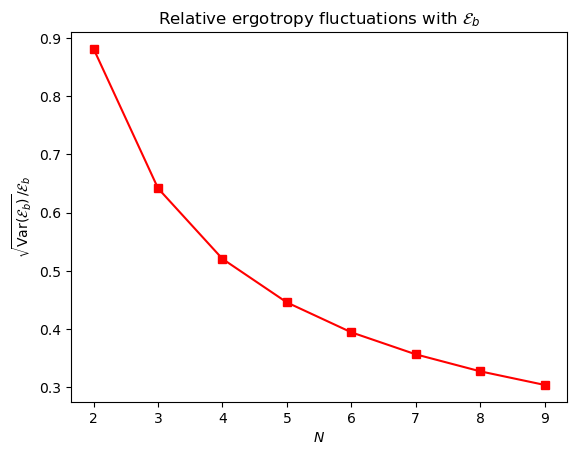

In [44]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={rel_fluct[idx]:.12f}, Relative Fluctuation with Eb ={rel_fluc[idx]:.12f}")

#######################################################################
# Plot fluctuations w.r.t ergotropy as a function of g for different N 
#######################################################################

plt.figure()
plt.plot(N_arr, rel_fluct, 's-', color='r')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations with $\mathcal{E}_b$")
#plt.savefig("WS4.png")
plt.show()

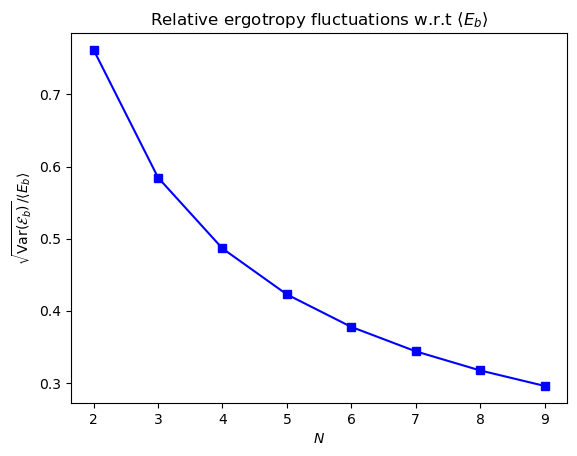

In [45]:
############################################################################
# Plot fluctuations w.r.t battery energy as a function of g for different N 
############################################################################

plt.figure()
plt.plot(N_arr, rel_fluc, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
#plt.savefig("WS5.png")
plt.show()

In [46]:
# =========================
# Check ground state of HB
# =========================

evals, evecs = HB.eigenstates()

psi0_all = qt.tensor([qt.basis(2,0) for _ in range(N)])  # |0...0>
psi1_all = qt.tensor([qt.basis(2,1) for _ in range(N)])  # |1...1>

E0 = qt.expect(HB, psi0_all)
E1 = qt.expect(HB, psi1_all)

print(f"\nN = {N}")
print(f"Ground energy (from diagonalization): {evals[0]:.4f}")
print(f"Energy of |0...0>: {E0:.4f}")
print(f"Energy of |1...1>: {E1:.4f}")

print("Is |0...0> ground state?", np.isclose(E0, evals[0]))
print("Is |1...1> ground state?", np.isclose(E1, evals[0]))


N = 9
Ground energy (from diagonalization): 0.0000
Energy of |0...0>: 9.0000
Energy of |1...1>: 0.0000
Is |0...0> ground state? False
Is |1...1> ground state? True
